In [1]:
import torch
import torch.nn as nn

import torchvision 
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [4]:
# Creating a transform to normalize the images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# We can also create a target_transform if needed
""" target_transform = transforms.Compose([
    transforms.Lambda(lambda y: torch.zeros(10, dtype = torch.float).scatter_(0, torch.tensor(y), value = 1))
])
"""

' target_transform = transforms.Compose([\n    transforms.Lambda(lambda y: torch.zeros(10, dtype = torch.float).scatter_(0, torch.tensor(y), value = 1))\n])\n'

In [ ]:
full_train_set = torchvision.datasets.CIFAR10(root = "./data", train = True, download = False, transform = transform)

test_set = torchvision.datasets.CIFAR10(root = "./data", train = False, download = False, transform = transform)

100%|██████████| 170M/170M [00:56<00:00, 3.03MB/s] 


In [6]:
# Defining the size of the validation set
val_size = 10000
train_size = len(full_train_set) - val_size

In [7]:
train_subset, val_subset = torch.utils.data.random_split(full_train_set, [train_size, val_size])

print(f"Full training set size: {len(full_train_set)}")
print(f"New training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")
print(f"Test set size: {len(test_set)}")

Full training set size: 50000
New training set size: 40000
Validation set size: 10000
Test set size: 10000


In [8]:
batch_size = 64

train_loader = DataLoader(dataset = train_subset, batch_size = batch_size, shuffle = True)
val_loader = DataLoader(dataset = val_subset, batch_size = batch_size, shuffle  = False)
test_loader = DataLoader(dataset = test_set, batch_size = batch_size, shuffle = False)

In [9]:
# Model using Model Subclassing
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding = 1)
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 1, padding = 1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(in_features = 32 * 8 * 8, out_features = 128)
        self.fc2 = nn.Linear(in_features = 128, out_features = 10)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")


Using device: cuda:0


In [11]:
model_subclassing = SimpleCNN().to(device)

In [12]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_subclassing.parameters(), lr = 0.01)
n_epochs = 10

In [19]:
def evaluate_model(model, data_loader, loss_function, device):
    # Evaluates the model on the given dataset
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = loss_function(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    avg_loss = running_loss / len(data_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy
            

In [21]:
def training_loop(model, train_loader, val_loader, test_loader, loss_function, optimizer, n_epochs, device):
    
    history = {
        "train_losses" : [], "train_accs": [],
        "val_losses": [], "val_accs": [],
        "test_losses": [], "test_accs": []
    }
    
    for epoch in range(n_epochs):
        # Training Phase
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        avg_train_loss = running_train_loss / len(train_loader)
        avg_train_acc = 100 * train_correct / train_total
        
        
        # Evaluation Phase
        val_loss, val_acc = evaluate_model(model, val_loader, loss_function, device)
        test_loss, test_acc = evaluate_model(model, test_loader, loss_function, device)
        
        history['train_losses'].append(avg_train_loss)
        history['train_accs'].append(avg_train_acc)
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)
        history['test_losses'].append(test_loss)
        history['test_accs'].append(test_acc)
        
        print(f"Epoch [{epoch + 1}/{n_epochs}] | "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
        
    print("Finished Training!")
    return history

In [27]:
import matplotlib.pyplot as plt

def plot_metrics(history):
    """Plots the training, validation, and test metrics."""
    epochs = range(1, len(history['train_losses']) + 1)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot Loss
    ax1.plot(epochs, history['train_losses'], 'o-', label='Training Loss')
    ax1.plot(epochs, history['val_losses'], 'o-', label='Validation Loss')
    ax1.plot(epochs, history['test_losses'], 'o-', label='Test Loss')
    ax1.set_title('Loss vs. Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.set_xticks(epochs)


    # Plot Accuracy
    ax2.plot(epochs, history['train_accs'], 'o-', label='Training Accuracy')
    ax2.plot(epochs, history['val_accs'], 'o-', label='Validation Accuracy')
    ax2.plot(epochs, history['test_accs'], 'o-', label='Test Accuracy')
    ax2.set_title('Accuracy vs. Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.set_xticks(epochs)

    plt.tight_layout()
    plt.show()

In [28]:
training_history = training_loop(model = model_subclassing,
                                 train_loader = train_loader,
                                 val_loader = val_loader, 
                                 test_loader = test_loader, 
                                 loss_function = loss_fn,
                                 optimizer = optimizer,
                                 n_epochs = n_epochs,
                                 device = device)

Epoch [1/10] | Train Loss: 1.0741, Train Acc: 61.88% | Val Loss: 1.3146, Val Acc: 55.66% | Test Loss: 1.2915, Test Acc: 56.46%
Epoch [2/10] | Train Loss: 1.0644, Train Acc: 62.49% | Val Loss: 1.3369, Val Acc: 54.51% | Test Loss: 1.3554, Test Acc: 54.86%
Epoch [3/10] | Train Loss: 1.0643, Train Acc: 62.56% | Val Loss: 1.3256, Val Acc: 55.41% | Test Loss: 1.3213, Test Acc: 55.44%
Epoch [4/10] | Train Loss: 1.0437, Train Acc: 63.18% | Val Loss: 1.3538, Val Acc: 55.21% | Test Loss: 1.3338, Test Acc: 55.86%
Epoch [5/10] | Train Loss: 1.0430, Train Acc: 63.13% | Val Loss: 1.3075, Val Acc: 56.84% | Test Loss: 1.3079, Test Acc: 56.93%
Epoch [6/10] | Train Loss: 1.0432, Train Acc: 63.42% | Val Loss: 1.3654, Val Acc: 54.50% | Test Loss: 1.3563, Test Acc: 54.23%
Epoch [7/10] | Train Loss: 1.0294, Train Acc: 63.67% | Val Loss: 1.3806, Val Acc: 54.91% | Test Loss: 1.3597, Test Acc: 56.05%
Epoch [8/10] | Train Loss: 1.0221, Train Acc: 63.88% | Val Loss: 1.3670, Val Acc: 55.39% | Test Loss: 1.3526, T

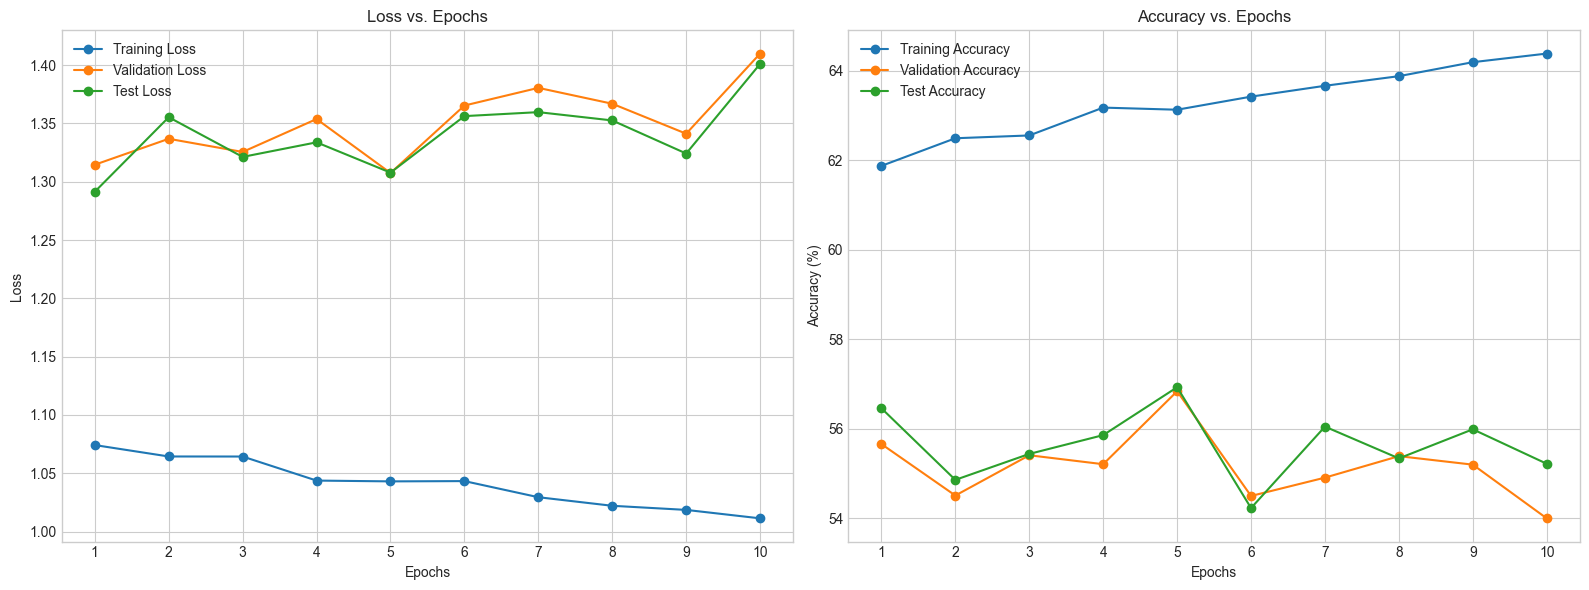

In [29]:
plot_metrics(training_history)

In [30]:
final_test_loss, final_test_acc = evaluate_model(model_subclassing, test_loader, loss_fn, device)

In [31]:
print(f'\nFinal accuracy on the 10000 test images: {final_test_acc:.2f}%')


Final accuracy on the 10000 test images: 55.22%
